Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.45288086..1.1503906].



=== Inspecting real-test d415_dataset: /home/cago/MMI_714_generative_models/term_project/dataset/real-test/d415_dataset ===
File: 000000000-opaque-depth-img.exr
  - Type (suffix): opaque-depth-img.exr
  - Resolution: 848x480
  - Channels: 3
  - DataType: float32
  - Min/Max: 0.4529 / 1.1504


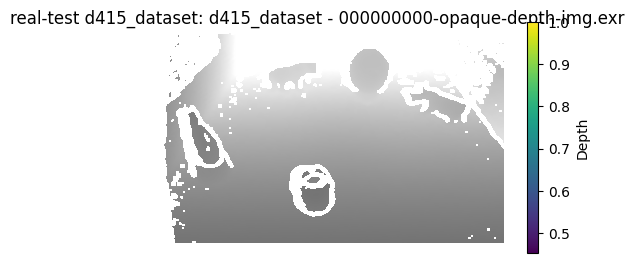

File: 000000000-opaque-rgb-img.jpg
  - Type (suffix): opaque-rgb-img.jpg
  - Resolution: 848x480
  - Channels: 3
  - DataType: uint8
  - Min/Max: 0.0000 / 255.0000


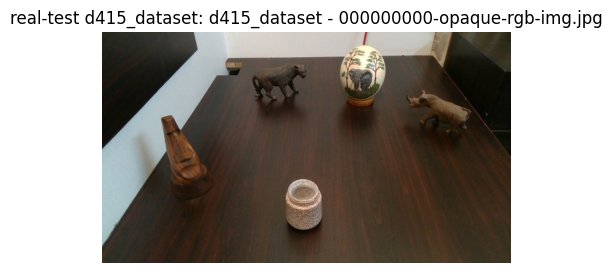

File: 000000000-transparent-depth-img.exr
  - Type (suffix): transparent-depth-img.exr
  - Resolution: 848x480
  - Channels: 3
  - DataType: float32
  - Min/Max: 0.0000 / 1.1484
File: 000000000-transparent-rgb-img.jpg
  - Type (suffix): transparent-rgb-img.jpg
  - Resolution: 848x480
  - Channels: 3
  - DataType: uint8
  - Min/Max: 0.0000 / 255.0000
------------------------------------------------------------

=== Inspecting real-test d435_dataset: /home/cago/MMI_714_generative_models/term_project/dataset/real-test/d435_dataset ===
File: 000000000-opaque-depth-img.exr
  - Type (suffix): opaque-depth-img.exr
  - Resolution: 1280x720
  - Channels: 3
  - DataType: float32
  - Min/Max: 0.0000 / 1.0000


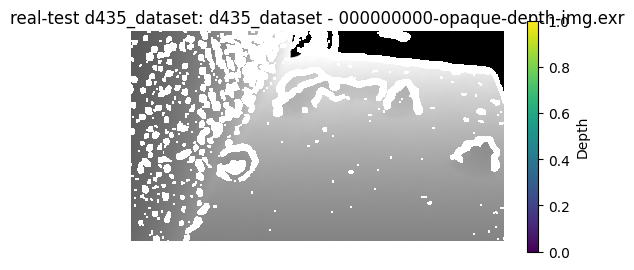

File: 000000000-opaque-rgb-img.jpg
  - Type (suffix): opaque-rgb-img.jpg
  - Resolution: 1280x720
  - Channels: 3
  - DataType: uint8
  - Min/Max: 0.0000 / 255.0000


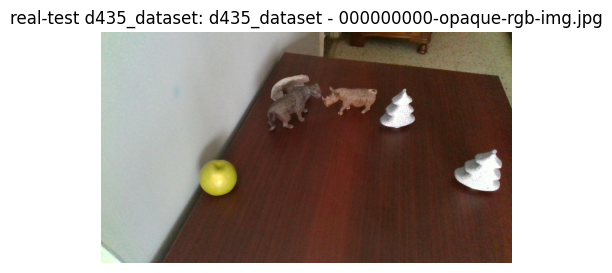

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0361328].


File: 000000000-transparent-depth-img.exr
  - Type (suffix): transparent-depth-img.exr
  - Resolution: 1280x720
  - Channels: 3
  - DataType: float32
  - Min/Max: 0.0000 / 1.0000
File: 000000000-transparent-rgb-img.jpg
  - Type (suffix): transparent-rgb-img.jpg
  - Resolution: 1280x720
  - Channels: 3
  - DataType: uint8
  - Min/Max: 0.0000 / 255.0000
------------------------------------------------------------

=== Inspecting real-val d435_dataset: /home/cago/MMI_714_generative_models/term_project/dataset/real-val/d435_dataset ===
File: 000000000-opaque-depth-img.exr
  - Type (suffix): opaque-depth-img.exr
  - Resolution: 1280x720
  - Channels: 3
  - DataType: float32
  - Min/Max: 0.0000 / 1.0361


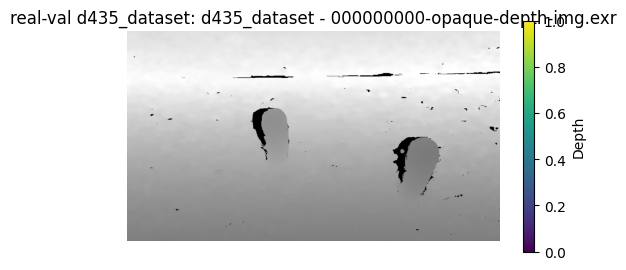

File: 000000000-opaque-rgb-img.jpg
  - Type (suffix): opaque-rgb-img.jpg
  - Resolution: 1280x720
  - Channels: 3
  - DataType: uint8
  - Min/Max: 0.0000 / 167.0000


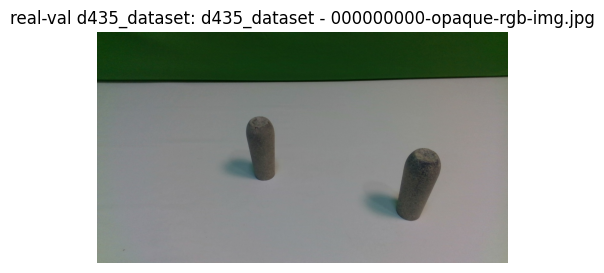

File: 000000000-transparent-depth-img.exr
  - Type (suffix): transparent-depth-img.exr
  - Resolution: 1280x720
  - Channels: 3
  - DataType: float32
  - Min/Max: 0.0000 / 1.0303
File: 000000000-transparent-rgb-img.jpg
  - Type (suffix): transparent-rgb-img.jpg
  - Resolution: 1280x720
  - Channels: 3
  - DataType: uint8
  - Min/Max: 0.0000 / 255.0000
------------------------------------------------------------


In [3]:
import os
os.environ["OPENCV_IO_ENABLE_OPENEXR"] = "1"
import cv2
import numpy as np
import matplotlib.pyplot as plt

IMG_EXTS = ('.exr', '.png', '.jpg', '.jpeg')

def inspect_flat_folder(path, title_prefix=""):
    """Inspect a single folder that directly contains images."""
    if not os.path.exists(path):
        print(f"Path does not exist: {path}")
        return

    print(f"\n=== Inspecting {title_prefix}{path} ===")

    files = sorted([f for f in os.listdir(path) if f.lower().endswith(IMG_EXTS)])
    if not files:
        print("No image files found.")
        return

    # group by suffix/type (normals, opaque-depth-img, rgb, etc.)
    sample_types = {}
    for f in files:
        parts = f.split('-')
        if len(parts) > 1:
            suffix = '-'.join(parts[1:])  # e.g. "opaque-depth-img.exr"
        else:
            suffix = f
        sample_types.setdefault(suffix, f)

    viz_flags = {'depth': False, 'normals': False, 'rgb': False}

    for suffix, filename in sample_types.items():
        filepath = os.path.join(path, filename)

        img = cv2.imread(filepath, cv2.IMREAD_UNCHANGED)
        if img is None:
            print(f"Could not read {filename}")
            continue

        h, w = img.shape[:2]
        c = img.shape[2] if img.ndim == 3 else 1

        print(f"File: {filename}")
        print(f"  - Type (suffix): {suffix}")
        print(f"  - Resolution: {w}x{h}")
        print(f"  - Channels: {c}")
        print(f"  - DataType: {img.dtype}")
        print(f"  - Min/Max: {np.nanmin(img):.4f} / {np.nanmax(img):.4f}")

        # visualize one depth map
        if ('depth' in suffix and not viz_flags['depth']):
            plt.figure(figsize=(6, 3))
            plt.title(f"{title_prefix}{os.path.basename(path)} - {filename}")
            viz_img = img.astype(np.float32).copy()
            viz_img[np.isinf(viz_img)] = np.nan
            plt.imshow(viz_img, cmap='viridis')
            plt.colorbar(label='Depth')
            plt.axis('off')
            plt.show()
            viz_flags['depth'] = True

        # visualize one normal map
        if ('normals' in suffix and not viz_flags['normals']):
            plt.figure(figsize=(6, 3))
            plt.title(f"{title_prefix}{os.path.basename(path)} - {filename}")
            viz_img = img.astype(np.float32)
            if img.dtype == np.float32 or img.dtype == np.float64:
                viz_img = (viz_img + 1.0) / 2.0
            else:
                viz_img = viz_img / 255.0
            if viz_img.ndim == 3 and viz_img.shape[2] == 3:
                viz_img = cv2.cvtColor(viz_img, cv2.COLOR_BGR2RGB)
            plt.imshow(np.clip(viz_img, 0, 1))
            plt.axis('off')
            plt.show()
            viz_flags['normals'] = True

        # visualize one rgb image
        if ('rgb' in suffix and not viz_flags['rgb']):
            if img.ndim == 3:
                rgb_viz = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            else:
                rgb_viz = img
            plt.figure(figsize=(6, 3))
            plt.title(f"{title_prefix}{os.path.basename(path)} - {filename}")
            plt.imshow(rgb_viz)
            plt.axis('off')
            plt.show()
            viz_flags['rgb'] = True

    print("-" * 60)


# ---- Run inspections on the three dataset folders ----

inspect_flat_folder(
    "/home/cago/MMI_714_generative_models/term_project/dataset/real-test/d415_dataset",
    title_prefix="real-test d415_dataset: "
)

inspect_flat_folder(
    "/home/cago/MMI_714_generative_models/term_project/dataset/real-test/d435_dataset",
    title_prefix="real-test d435_dataset: "
)

inspect_flat_folder(
    "/home/cago/MMI_714_generative_models/term_project/dataset/real-val/d435_dataset",
    title_prefix="real-val d435_dataset: "
)

In [1]:
import os
import shutil

src_dir = "/home/cago/MMI_714_generative_models/term_project/dataset/real-val/d435"
dst_dir = "/home/cago/MMI_714_generative_models/term_project/dataset/real-val/d435_dataset"

os.makedirs(dst_dir, exist_ok=True)

# suffixes we want to keep
keep_suffixes = (
    "-opaque-depth-img.exr",
    "-opaque-rgb-img.jpg",
    "-transparent-depth-img.exr",
    "-transparent-rgb-img.jpg",
)

for fname in os.listdir(src_dir):
    src_path = os.path.join(src_dir, fname)
    if not os.path.isfile(src_path):
        continue

    if fname.endswith(keep_suffixes):
        dst_path = os.path.join(dst_dir, fname)
        shutil.copy2(src_path, dst_path)
        print(f"Copied: {fname}")

print("Done.")

Copied: 000000082-opaque-depth-img.exr
Copied: 000000100-transparent-depth-img.exr
Copied: 000000063-opaque-rgb-img.jpg
Copied: 000000147-opaque-depth-img.exr
Copied: 000000023-transparent-depth-img.exr
Copied: 000000102-transparent-depth-img.exr
Copied: 000000073-transparent-rgb-img.jpg
Copied: 000000108-transparent-rgb-img.jpg
Copied: 000000023-opaque-depth-img.exr
Copied: 000000096-opaque-depth-img.exr
Copied: 000000040-opaque-depth-img.exr
Copied: 000000006-opaque-depth-img.exr
Copied: 000000035-transparent-rgb-img.jpg
Copied: 000000003-opaque-rgb-img.jpg
Copied: 000000074-opaque-rgb-img.jpg
Copied: 000000089-opaque-depth-img.exr
Copied: 000000022-opaque-rgb-img.jpg
Copied: 000000002-transparent-depth-img.exr
Copied: 000000152-opaque-depth-img.exr
Copied: 000000001-opaque-depth-img.exr
Copied: 000000013-transparent-rgb-img.jpg
Copied: 000000027-transparent-rgb-img.jpg
Copied: 000000162-transparent-depth-img.exr
Copied: 000000125-opaque-rgb-img.jpg
Copied: 000000070-opaque-depth-img

In [2]:
import os
import shutil

base_dir = "/home/cago/MMI_714_generative_models/term_project/dataset/real-test"

# cameras we want to process
cams = ["d415", "d435"]

# suffixes we want to keep
keep_suffixes = (
    "-opaque-depth-img.exr",
    "-opaque-rgb-img.jpg",
    "-transparent-depth-img.exr",
    "-transparent-rgb-img.jpg",
)

for cam in cams:
    src_dir = os.path.join(base_dir, cam)
    dst_dir = os.path.join(base_dir, f"{cam}_dataset")

    if not os.path.exists(src_dir):
        print(f"Source folder does not exist, skipping: {src_dir}")
        continue

    os.makedirs(dst_dir, exist_ok=True)
    print(f"\nProcessing {cam}:")
    print(f"  From: {src_dir}")
    print(f"  To  : {dst_dir}")

    for fname in os.listdir(src_dir):
        src_path = os.path.join(src_dir, fname)
        if not os.path.isfile(src_path):
            continue

        if fname.endswith(keep_suffixes):
            dst_path = os.path.join(dst_dir, fname)
            shutil.copy2(src_path, dst_path)
            print(f"  Copied: {fname}")

print("Done real-test d415/d435.")


Processing d415:
  From: /home/cago/MMI_714_generative_models/term_project/dataset/real-test/d415
  To  : /home/cago/MMI_714_generative_models/term_project/dataset/real-test/d415_dataset
  Copied: 000000082-opaque-depth-img.exr
  Copied: 000000063-opaque-rgb-img.jpg
  Copied: 000000023-transparent-depth-img.exr
  Copied: 000000073-transparent-rgb-img.jpg
  Copied: 000000023-opaque-depth-img.exr
  Copied: 000000040-opaque-depth-img.exr
  Copied: 000000006-opaque-depth-img.exr
  Copied: 000000035-transparent-rgb-img.jpg
  Copied: 000000003-opaque-rgb-img.jpg
  Copied: 000000074-opaque-rgb-img.jpg
  Copied: 000000089-opaque-depth-img.exr
  Copied: 000000022-opaque-rgb-img.jpg
  Copied: 000000002-transparent-depth-img.exr
  Copied: 000000001-opaque-depth-img.exr
  Copied: 000000013-transparent-rgb-img.jpg
  Copied: 000000027-transparent-rgb-img.jpg
  Copied: 000000070-opaque-depth-img.exr
  Copied: 000000074-transparent-rgb-img.jpg
  Copied: 000000047-opaque-rgb-img.jpg
  Copied: 00000000


===== Class: cup-with-waves =====
Depth dir: /home/cago/MMI_714_generative_models/term_project/dataset/synthetic_dataset/cup-with-waves/depth-imgs-rectified
RGB dir  : /home/cago/MMI_714_generative_models/term_project/dataset/synthetic_dataset/cup-with-waves/rgb-imgs
  #depth EXR: 100
  #rgb JPG : 100

  Sample 1:
    Depth: 000000000-depth-rectified.exr
      - shape   : 1024x576, channels=3
      - dtype   : float32
      - min/max : 0.2460 / 0.5840
    RGB  : 000000000-rgb.jpg
      - shape   : 1024x576, channels=3
      - dtype   : uint8
      - min/max : 32 / 166


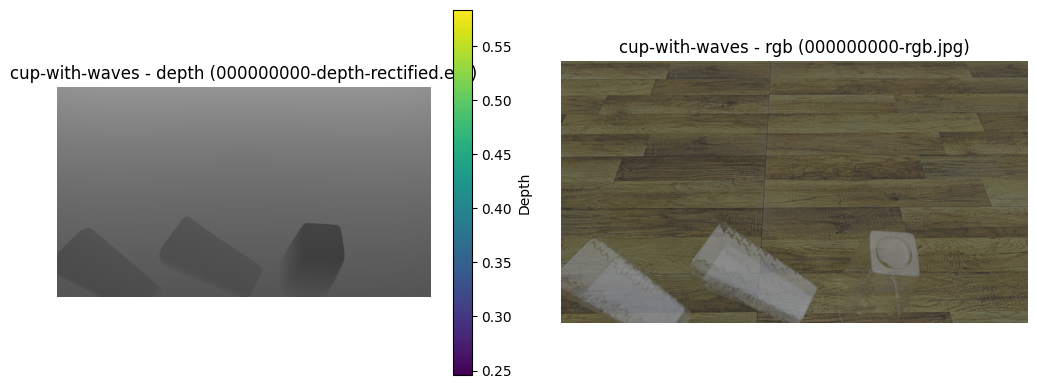


  Sample 2:
    Depth: 000000001-depth-rectified.exr
      - shape   : 1024x576, channels=3
      - dtype   : float32
      - min/max : 0.2791 / 0.6538
    RGB  : 000000001-rgb.jpg
      - shape   : 1024x576, channels=3
      - dtype   : uint8
      - min/max : 0 / 222


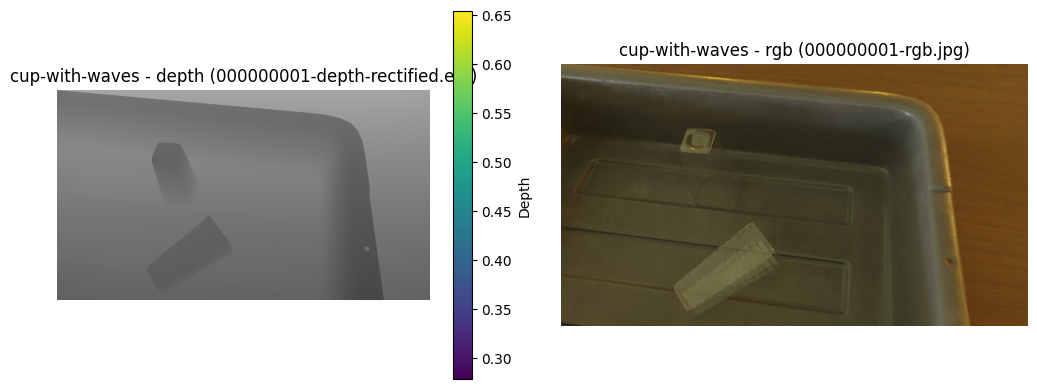

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.39086914..1.0107422].



  Sample 3:
    Depth: 000000002-depth-rectified.exr
      - shape   : 1024x576, channels=3
      - dtype   : float32
      - min/max : 0.3909 / 1.0107
    RGB  : 000000002-rgb.jpg
      - shape   : 1024x576, channels=3
      - dtype   : uint8
      - min/max : 26 / 247


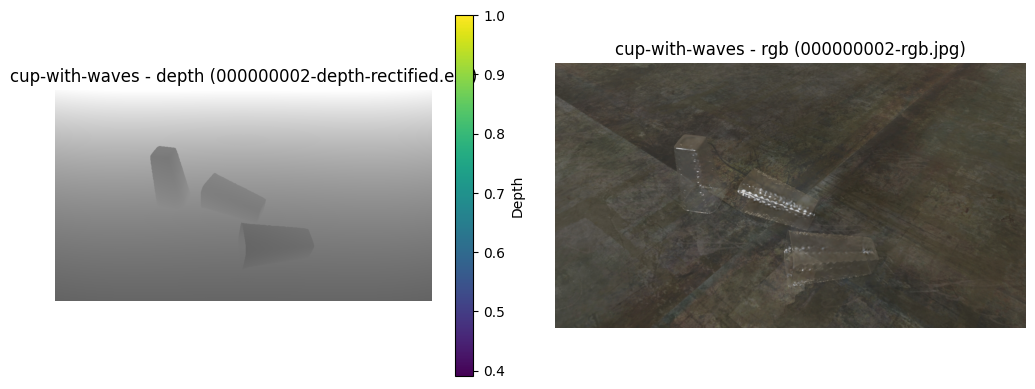

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.35546875..1.171875].



===== Class: flower-bath-bomb =====
Depth dir: /home/cago/MMI_714_generative_models/term_project/dataset/synthetic_dataset/flower-bath-bomb/depth-imgs-rectified
RGB dir  : /home/cago/MMI_714_generative_models/term_project/dataset/synthetic_dataset/flower-bath-bomb/rgb-imgs
  #depth EXR: 100
  #rgb JPG : 100

  Sample 1:
    Depth: 000000000-depth-rectified.exr
      - shape   : 1024x576, channels=3
      - dtype   : float32
      - min/max : 0.3555 / 1.1719
    RGB  : 000000000-rgb.jpg
      - shape   : 1024x576, channels=3
      - dtype   : uint8
      - min/max : 12 / 230


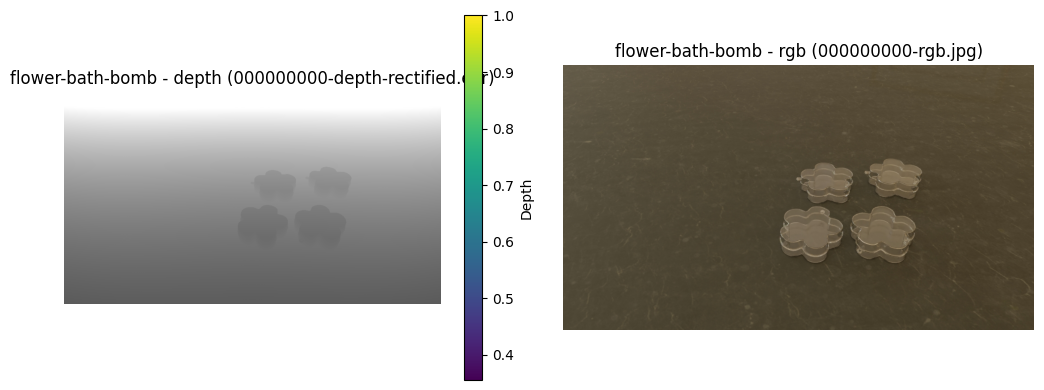


  Sample 2:
    Depth: 000000001-depth-rectified.exr
      - shape   : 1024x576, channels=3
      - dtype   : float32
      - min/max : 0.1870 / 0.4487
    RGB  : 000000001-rgb.jpg
      - shape   : 1024x576, channels=3
      - dtype   : uint8
      - min/max : 0 / 180


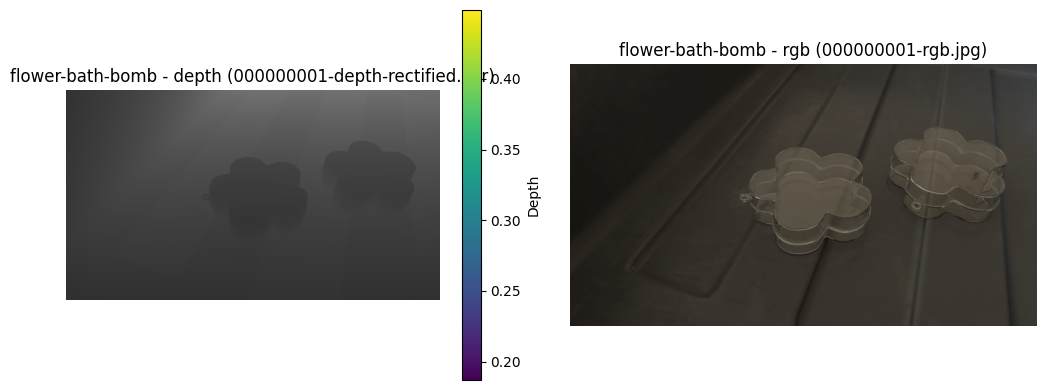


  Sample 3:
    Depth: 000000002-depth-rectified.exr
      - shape   : 1024x576, channels=3
      - dtype   : float32
      - min/max : 0.3047 / 0.6450
    RGB  : 000000002-rgb.jpg
      - shape   : 1024x576, channels=3
      - dtype   : uint8
      - min/max : 0 / 255


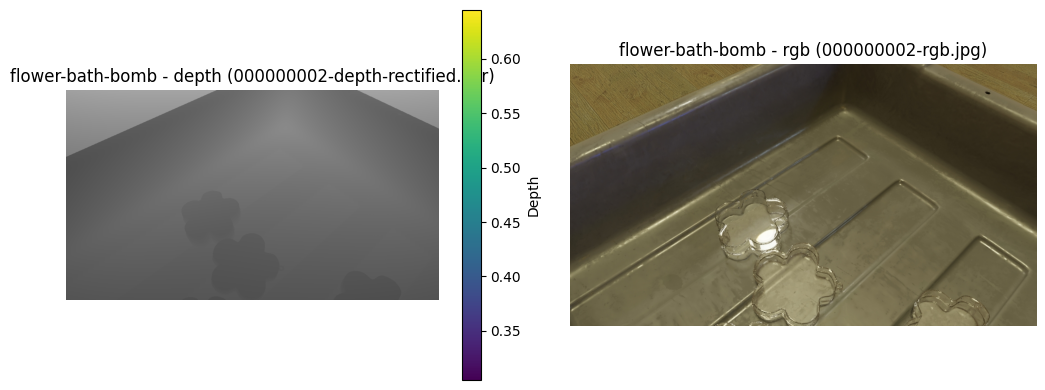

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.1845703..3.640625].



===== Class: glass-round-potion =====
Depth dir: /home/cago/MMI_714_generative_models/term_project/dataset/synthetic_dataset/glass-round-potion/depth-imgs-rectified
RGB dir  : /home/cago/MMI_714_generative_models/term_project/dataset/synthetic_dataset/glass-round-potion/rgb-imgs
  #depth EXR: 109
  #rgb JPG : 109

  Sample 1:
    Depth: 000000000-depth-rectified.exr
      - shape   : 1024x576, channels=3
      - dtype   : float32
      - min/max : 1.1846 / 3.6406
    RGB  : 000000000-rgb.jpg
      - shape   : 1024x576, channels=3
      - dtype   : uint8
      - min/max : 0 / 243


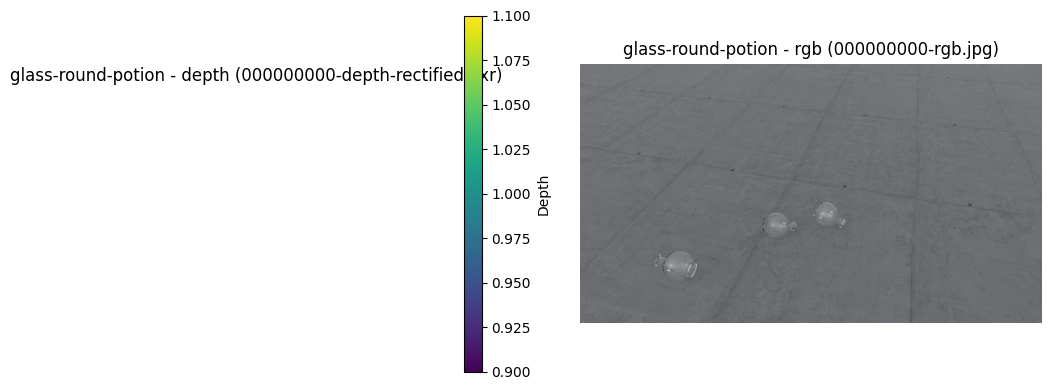

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.34033203..1.0224609].



  Sample 2:
    Depth: 000000001-depth-rectified.exr
      - shape   : 1024x576, channels=3
      - dtype   : float32
      - min/max : 0.3403 / 1.0225
    RGB  : 000000001-rgb.jpg
      - shape   : 1024x576, channels=3
      - dtype   : uint8
      - min/max : 0 / 255


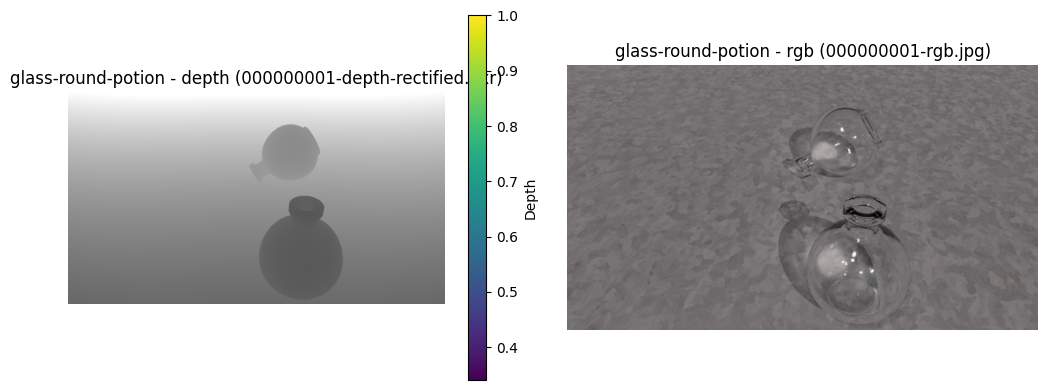


  Sample 3:
    Depth: 000000002-depth-rectified.exr
      - shape   : 1024x576, channels=3
      - dtype   : float32
      - min/max : 0.2010 / 0.7656
    RGB  : 000000002-rgb.jpg
      - shape   : 1024x576, channels=3
      - dtype   : uint8
      - min/max : 0 / 255


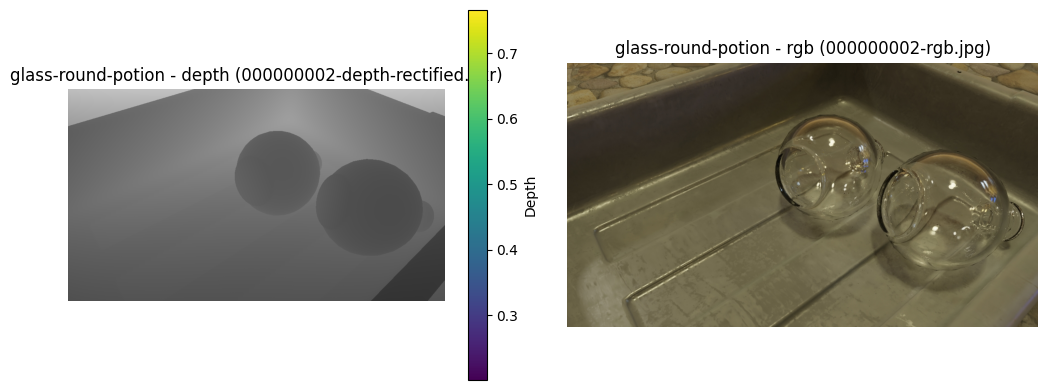


===== Class: glass-square-potion =====
Depth dir: /home/cago/MMI_714_generative_models/term_project/dataset/synthetic_dataset/glass-square-potion/depth-imgs-rectified
RGB dir  : /home/cago/MMI_714_generative_models/term_project/dataset/synthetic_dataset/glass-square-potion/rgb-imgs
  #depth EXR: 94
  #rgb JPG : 94

  Sample 1:
    Depth: 000000000-depth-rectified.exr
      - shape   : 1024x576, channels=3
      - dtype   : float32
      - min/max : 0.4075 / 0.8472
    RGB  : 000000000-rgb.jpg
      - shape   : 1024x576, channels=3
      - dtype   : uint8
      - min/max : 0 / 255


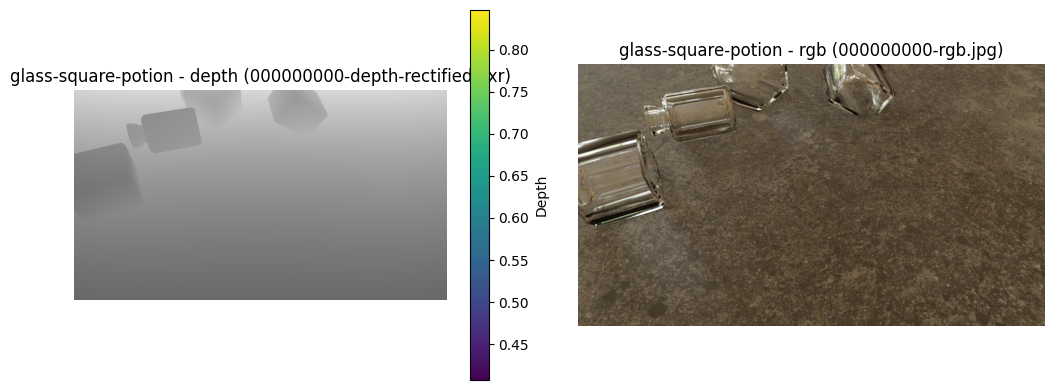

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.9013672..2.7675781].



  Sample 2:
    Depth: 000000001-depth-rectified.exr
      - shape   : 1024x576, channels=3
      - dtype   : float32
      - min/max : 0.9014 / 2.7676
    RGB  : 000000001-rgb.jpg
      - shape   : 1024x576, channels=3
      - dtype   : uint8
      - min/max : 0 / 235


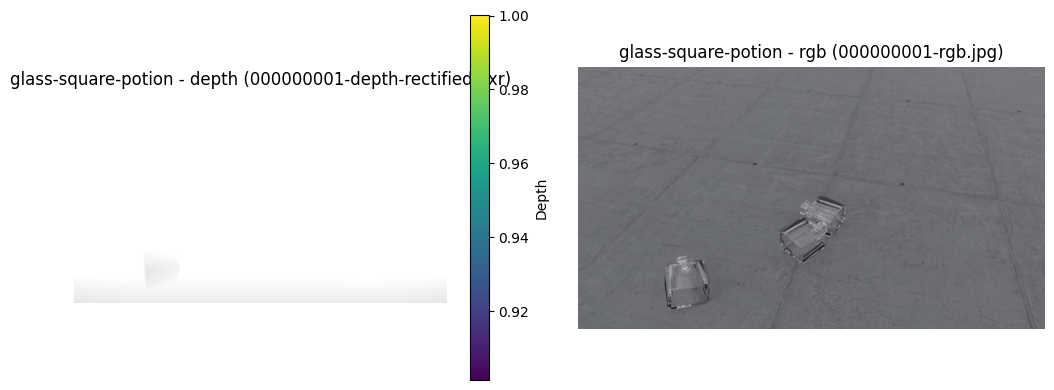


  Sample 3:
    Depth: 000000002-depth-rectified.exr
      - shape   : 1024x576, channels=3
      - dtype   : float32
      - min/max : 0.2452 / 0.8760
    RGB  : 000000002-rgb.jpg
      - shape   : 1024x576, channels=3
      - dtype   : uint8
      - min/max : 0 / 255


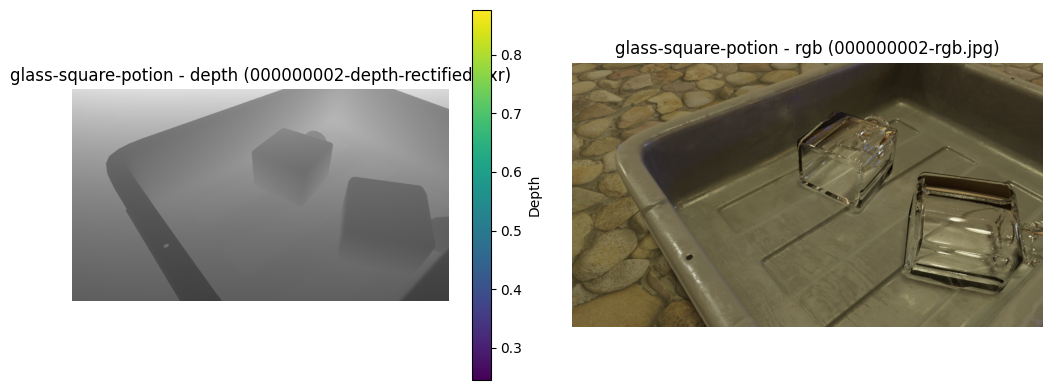


===== Class: heart-bath-bomb =====
Depth dir: /home/cago/MMI_714_generative_models/term_project/dataset/synthetic_dataset/heart-bath-bomb/depth-imgs-rectified
RGB dir  : /home/cago/MMI_714_generative_models/term_project/dataset/synthetic_dataset/heart-bath-bomb/rgb-imgs
  #depth EXR: 100
  #rgb JPG : 100

  Sample 1:
    Depth: 000000000-depth-rectified.exr
      - shape   : 1920x1080, channels=3
      - dtype   : float32
      - min/max : 0.3845 / 1.2451
    RGB  : 000000000-rgb.jpg
      - shape   : 1920x1080, channels=3
      - dtype   : uint8


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.38452148..1.2451172].


      - min/max : 0 / 254


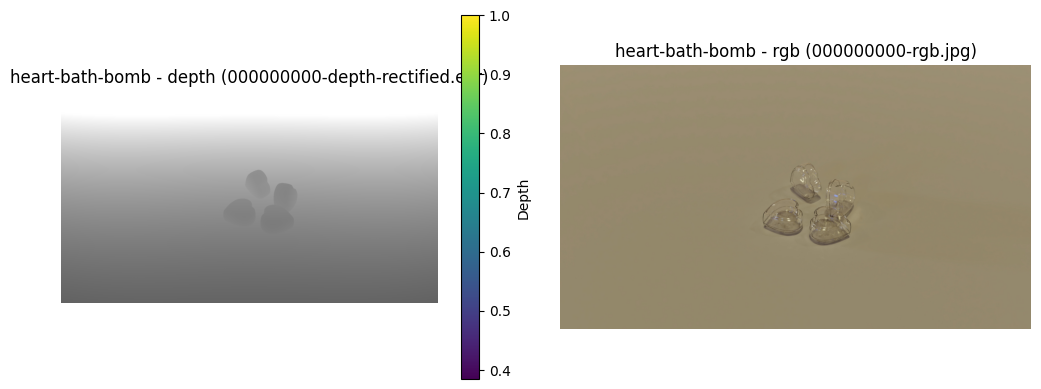


  Sample 2:
    Depth: 000000001-depth-rectified.exr
      - shape   : 1920x1080, channels=3
      - dtype   : float32
      - min/max : 0.4507 / 0.8003
    RGB  : 000000001-rgb.jpg
      - shape   : 1920x1080, channels=3
      - dtype   : uint8
      - min/max : 0 / 255


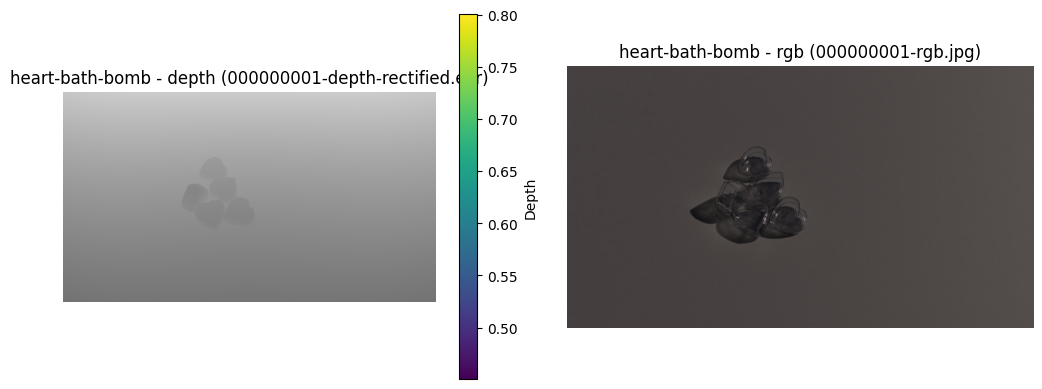

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.24169922..1.171875].



  Sample 3:
    Depth: 000000002-depth-rectified.exr
      - shape   : 1920x1080, channels=3
      - dtype   : float32
      - min/max : 0.2417 / 1.1719
    RGB  : 000000002-rgb.jpg
      - shape   : 1920x1080, channels=3
      - dtype   : uint8
      - min/max : 0 / 249


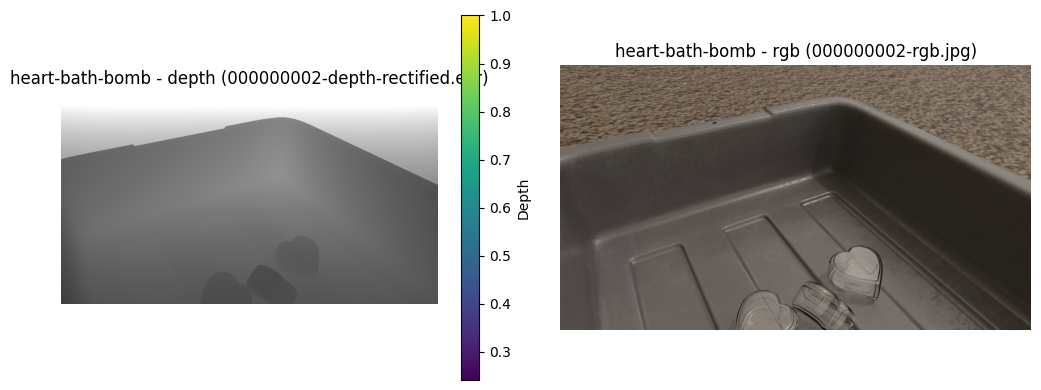

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.5180664..1.7871094].



===== Class: square-plastic-bottle =====
Depth dir: /home/cago/MMI_714_generative_models/term_project/dataset/synthetic_dataset/square-plastic-bottle/depth-imgs-rectified
RGB dir  : /home/cago/MMI_714_generative_models/term_project/dataset/synthetic_dataset/square-plastic-bottle/rgb-imgs
  #depth EXR: 115
  #rgb JPG : 115

  Sample 1:
    Depth: 000000000-depth-rectified.exr
      - shape   : 1920x1080, channels=3
      - dtype   : float32
      - min/max : 0.5181 / 1.7871
    RGB  : 000000000-rgb.jpg
      - shape   : 1920x1080, channels=3
      - dtype   : uint8
      - min/max : 0 / 254


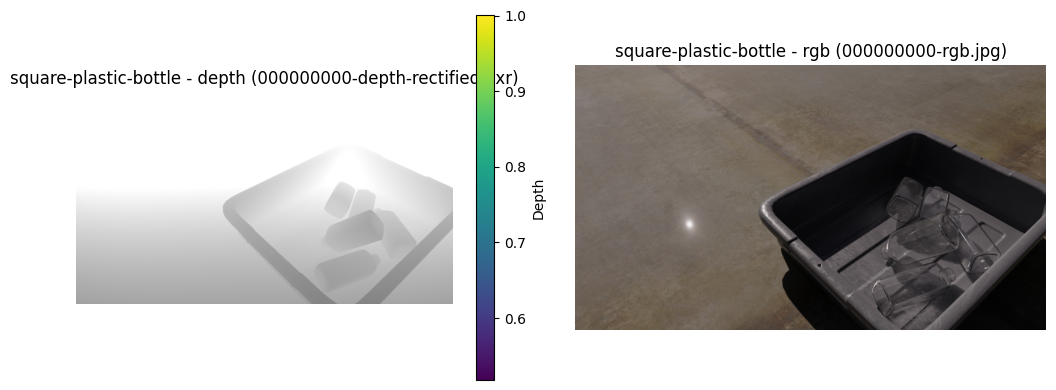

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.8569336..1.9277344].



  Sample 2:
    Depth: 000000001-depth-rectified.exr
      - shape   : 1920x1080, channels=3
      - dtype   : float32
      - min/max : 0.8569 / 1.9277
    RGB  : 000000001-rgb.jpg
      - shape   : 1920x1080, channels=3
      - dtype   : uint8
      - min/max : 37 / 208


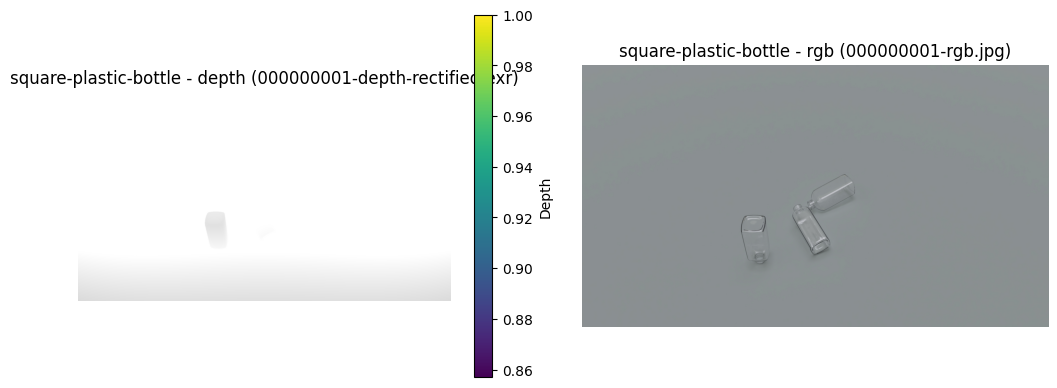

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.47509766..1.2294922].



  Sample 3:
    Depth: 000000002-depth-rectified.exr
      - shape   : 1920x1080, channels=3
      - dtype   : float32
      - min/max : 0.4751 / 1.2295
    RGB  : 000000002-rgb.jpg
      - shape   : 1920x1080, channels=3
      - dtype   : uint8
      - min/max : 45 / 253


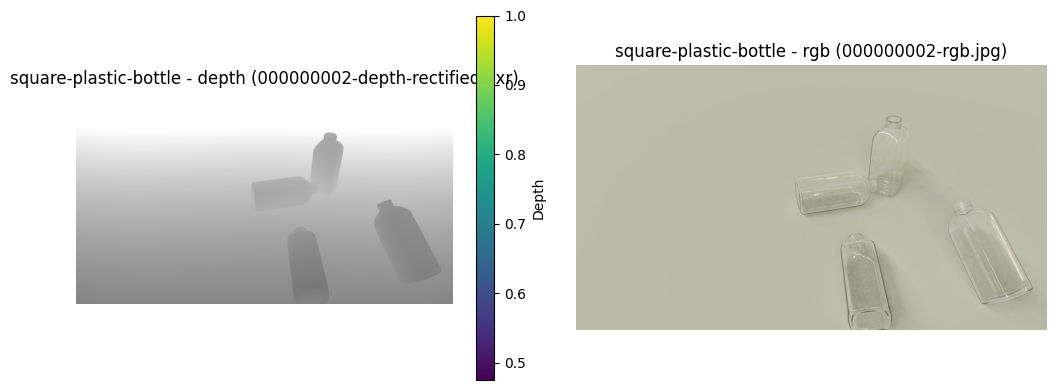


===== Class: star-bath-bomb =====
Depth dir: /home/cago/MMI_714_generative_models/term_project/dataset/synthetic_dataset/star-bath-bomb/depth-imgs-rectified
RGB dir  : /home/cago/MMI_714_generative_models/term_project/dataset/synthetic_dataset/star-bath-bomb/rgb-imgs
  #depth EXR: 98
  #rgb JPG : 98

  Sample 1:
    Depth: 000000000-depth-rectified.exr
      - shape   : 1024x576, channels=3
      - dtype   : float32
      - min/max : 0.2568 / 0.6694
    RGB  : 000000000-rgb.jpg
      - shape   : 1024x576, channels=3
      - dtype   : uint8
      - min/max : 0 / 254


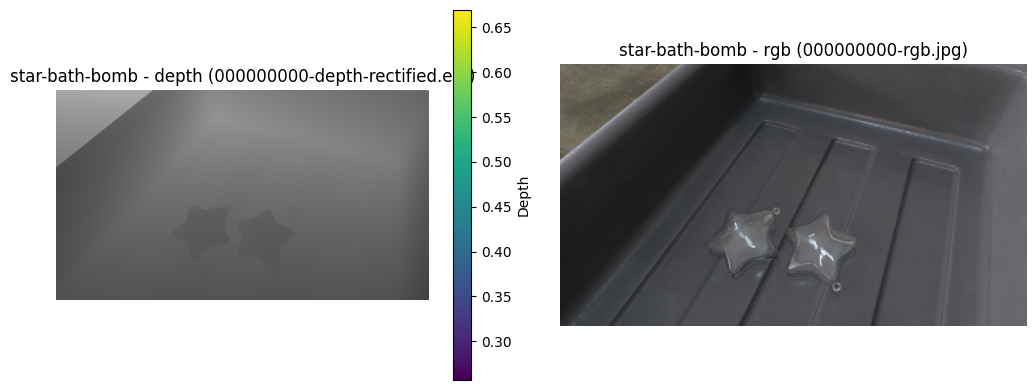

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.43041992..1.2646484].



  Sample 2:
    Depth: 000000001-depth-rectified.exr
      - shape   : 1024x576, channels=3
      - dtype   : float32
      - min/max : 0.4304 / 1.2646
    RGB  : 000000001-rgb.jpg
      - shape   : 1024x576, channels=3
      - dtype   : uint8
      - min/max : 0 / 255


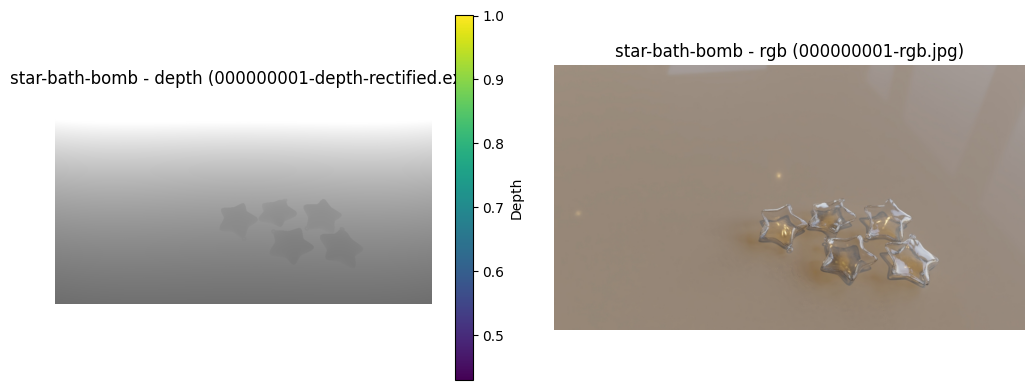


  Sample 3:
    Depth: 000000002-depth-rectified.exr
      - shape   : 1024x576, channels=3
      - dtype   : float32
      - min/max : 0.2423 / 0.5752
    RGB  : 000000002-rgb.jpg
      - shape   : 1024x576, channels=3
      - dtype   : uint8
      - min/max : 0 / 253


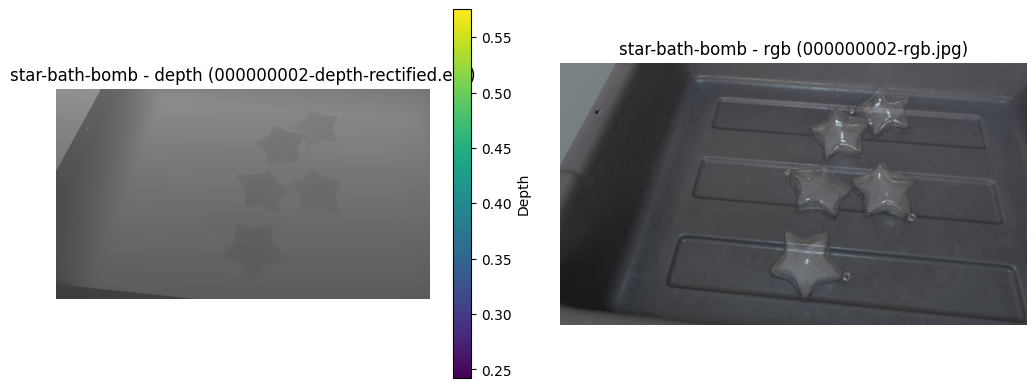


===== Class: stemless-plastic-champagne-glass =====
Depth dir: /home/cago/MMI_714_generative_models/term_project/dataset/synthetic_dataset/stemless-plastic-champagne-glass/depth-imgs-rectified
RGB dir  : /home/cago/MMI_714_generative_models/term_project/dataset/synthetic_dataset/stemless-plastic-champagne-glass/rgb-imgs
  #depth EXR: 117
  #rgb JPG : 117

  Sample 1:
    Depth: 000000000-depth-rectified.exr
      - shape   : 1920x1080, channels=3
      - dtype   : float32
      - min/max : 0.4741 / 1.1738
    RGB  : 000000000-rgb.jpg
      - shape   : 1920x1080, channels=3
      - dtype   : uint8
      - min/max : 0 / 255


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.4741211..1.1738281].


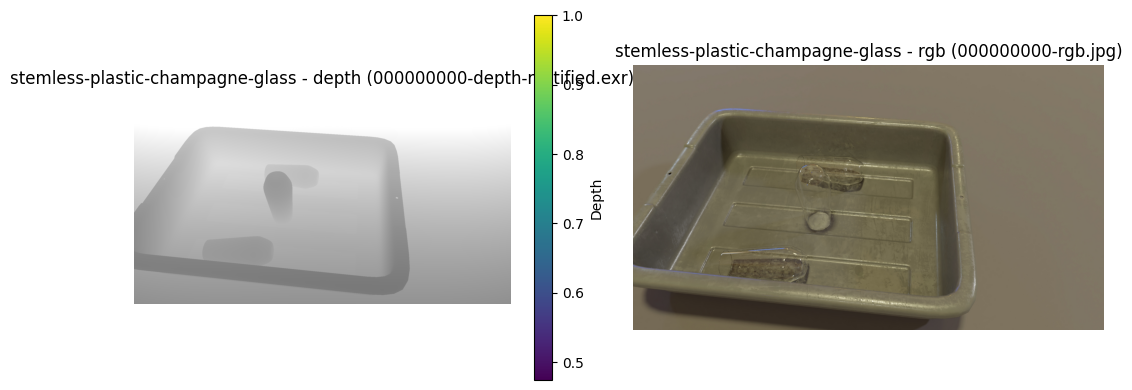

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.36376953..1.0380859].



  Sample 2:
    Depth: 000000001-depth-rectified.exr
      - shape   : 1920x1080, channels=3
      - dtype   : float32
      - min/max : 0.3638 / 1.0381
    RGB  : 000000001-rgb.jpg
      - shape   : 1920x1080, channels=3
      - dtype   : uint8
      - min/max : 0 / 255


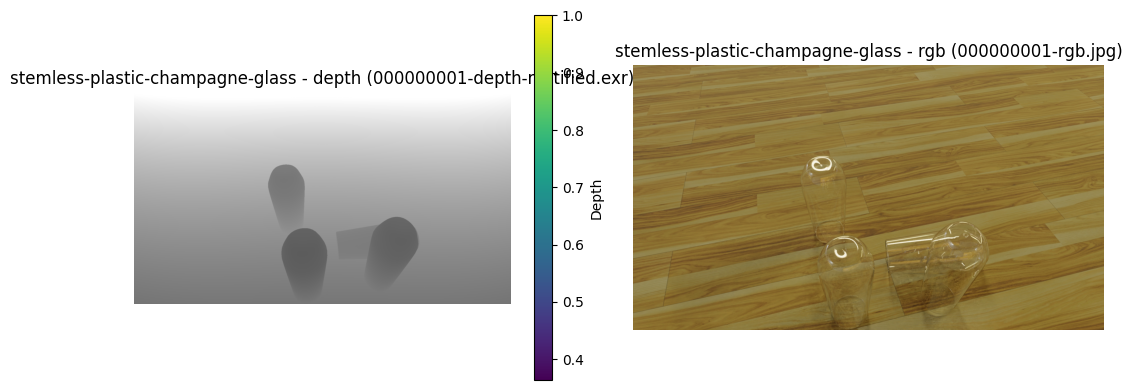

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.69433594..2.5351562].



  Sample 3:
    Depth: 000000002-depth-rectified.exr
      - shape   : 1920x1080, channels=3
      - dtype   : float32
      - min/max : 0.6943 / 2.5352
    RGB  : 000000002-rgb.jpg
      - shape   : 1920x1080, channels=3
      - dtype   : uint8
      - min/max : 0 / 248


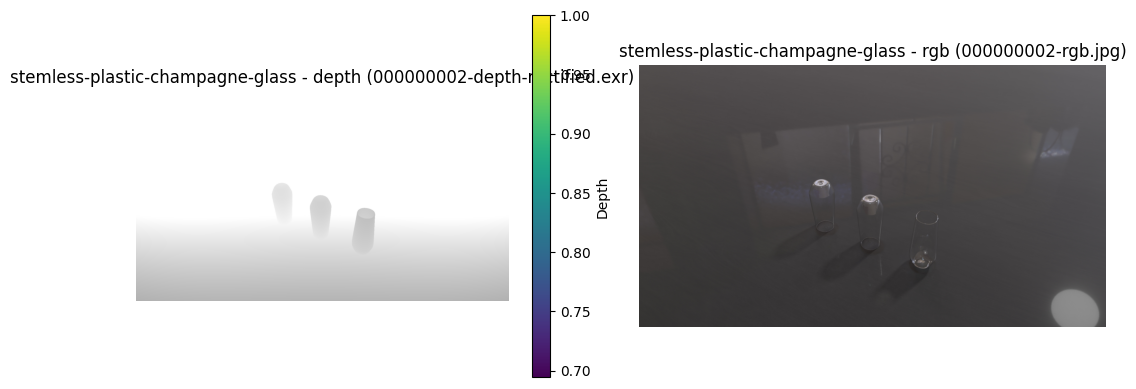


===== Class: tree-bath-bomb =====
Depth dir: /home/cago/MMI_714_generative_models/term_project/dataset/synthetic_dataset/tree-bath-bomb/depth-imgs-rectified
RGB dir  : /home/cago/MMI_714_generative_models/term_project/dataset/synthetic_dataset/tree-bath-bomb/rgb-imgs
  #depth EXR: 107
  #rgb JPG : 107

  Sample 1:
    Depth: 000000000-depth-rectified.exr
      - shape   : 1024x576, channels=3
      - dtype   : float32
      - min/max : 0.1881 / 0.5156
    RGB  : 000000000-rgb.jpg
      - shape   : 1024x576, channels=3
      - dtype   : uint8
      - min/max : 0 / 242


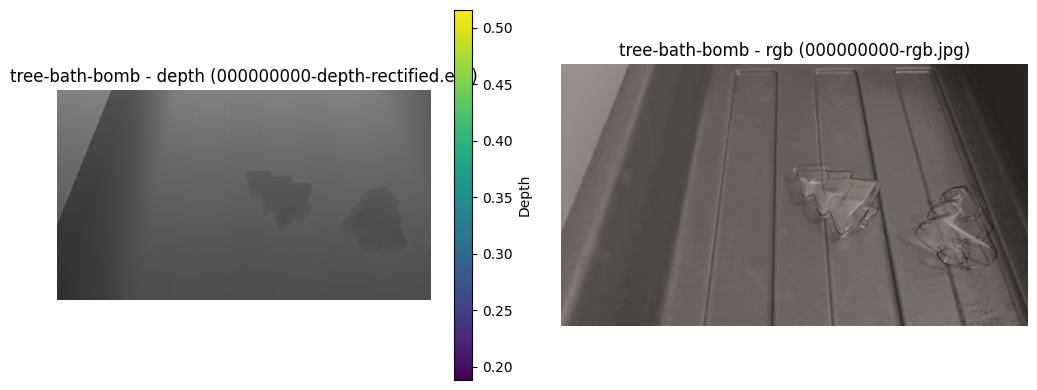

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.53759766..1.1923828].



  Sample 2:
    Depth: 000000001-depth-rectified.exr
      - shape   : 1024x576, channels=3
      - dtype   : float32
      - min/max : 0.5376 / 1.1924
    RGB  : 000000001-rgb.jpg
      - shape   : 1024x576, channels=3
      - dtype   : uint8
      - min/max : 0 / 249


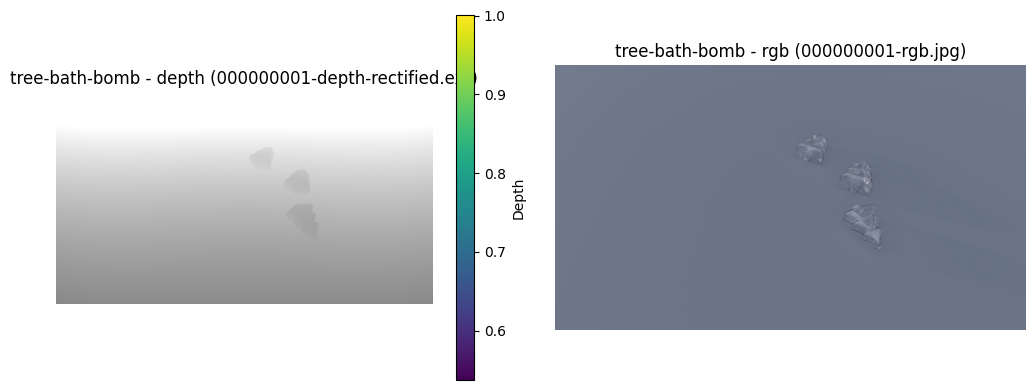


  Sample 3:
    Depth: 000000002-depth-rectified.exr
      - shape   : 1024x576, channels=3
      - dtype   : float32
      - min/max : 0.4128 / 0.8330
    RGB  : 000000002-rgb.jpg
      - shape   : 1024x576, channels=3
      - dtype   : uint8
      - min/max : 41 / 238


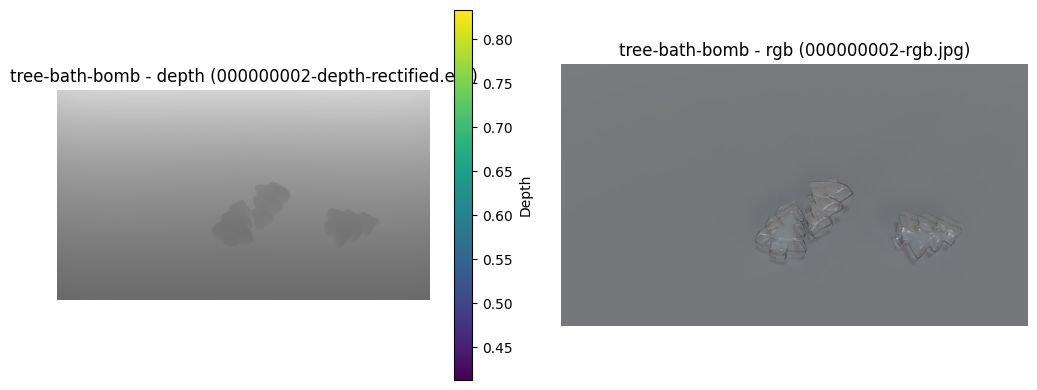

In [1]:

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
os.environ["OPENCV_IO_ENABLE_OPENEXR"] = "1"

synthetic_root = "/home/cago/MMI_714_generative_models/term_project/dataset/synthetic_dataset"

# list all class folders
class_names = sorted(
    d for d in os.listdir(synthetic_root)
    if os.path.isdir(os.path.join(synthetic_root, d))
)

def analyze_depth_rgb_for_class(class_name, max_samples=3):
    class_path = os.path.join(synthetic_root, class_name)
    depth_dir = os.path.join(class_path, "depth-imgs-rectified")
    rgb_dir   = os.path.join(class_path, "rgb-imgs")

    print(f"\n===== Class: {class_name} =====")
    print(f"Depth dir: {depth_dir}")
    print(f"RGB dir  : {rgb_dir}")

    if not os.path.exists(depth_dir):
        print("  [!] depth-imgs-rectified not found, skipping.")
        return
    if not os.path.exists(rgb_dir):
        print("  [!] rgb-imgs not found, skipping.")
        return

    depth_files = sorted([f for f in os.listdir(depth_dir) if f.lower().endswith(".exr")])
    rgb_files   = sorted([f for f in os.listdir(rgb_dir)   if f.lower().endswith(".jpg")])

    print(f"  #depth EXR: {len(depth_files)}")
    print(f"  #rgb JPG : {len(rgb_files)}")

    # analyze up to max_samples matched by index
    n = min(max_samples, len(depth_files), len(rgb_files))
    for i in range(n):
        dname = depth_files[i]
        rname = rgb_files[i]

        dpath = os.path.join(depth_dir, dname)
        rpath = os.path.join(rgb_dir, rname)

        depth = cv2.imread(dpath, cv2.IMREAD_UNCHANGED)
        rgb   = cv2.imread(rpath, cv2.IMREAD_COLOR)

        if depth is None:
            print(f"  Could not read depth: {dname}")
            continue
        if rgb is None:
            print(f"  Could not read rgb  : {rname}")
            continue

        # depth stats
        dh, dw = depth.shape[:2]
        print(f"\n  Sample {i+1}:")
        print(f"    Depth: {dname}")
        print(f"      - shape   : {dw}x{dh}, channels={1 if depth.ndim==2 else depth.shape[2]}")
        print(f"      - dtype   : {depth.dtype}")
        print(f"      - min/max : {np.nanmin(depth):.4f} / {np.nanmax(depth):.4f}")

        # rgb stats
        rh, rw = rgb.shape[:2]
        print(f"    RGB  : {rname}")
        print(f"      - shape   : {rw}x{rh}, channels={rgb.shape[2]}")
        print(f"      - dtype   : {rgb.dtype}")
        print(f"      - min/max : {rgb.min()} / {rgb.max()}")

        # visualize pair
        plt.figure(figsize=(10, 4))

        plt.subplot(1, 2, 1)
        depth_viz = depth.astype(np.float32).copy()
        depth_viz[np.isinf(depth_viz)] = np.nan
        plt.imshow(depth_viz, cmap="viridis")
        plt.title(f"{class_name} - depth ({dname})")
        plt.colorbar(label="Depth")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        rgb_viz = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)
        plt.imshow(rgb_viz)
        plt.title(f"{class_name} - rgb ({rname})")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

# run analysis for all classes
for cname in class_names:
    analyze_depth_rgb_for_class(cname, max_samples=3)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..101.0].


File 1: 000000000-variantMasks.exr
  - shape   : (576, 1024, 4)
  - dtype   : float32
  - min/max : 0.0000 / 101.0000


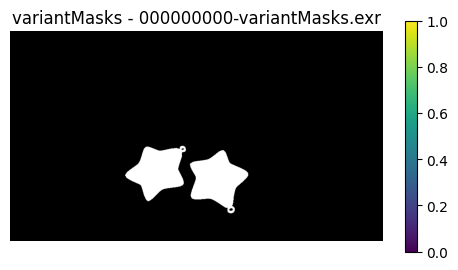

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..104.0].


File 2: 000000001-variantMasks.exr
  - shape   : (576, 1024, 4)
  - dtype   : float32
  - min/max : 0.0000 / 104.0000


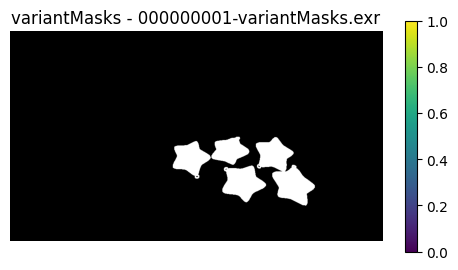

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..104.0].


File 3: 000000002-variantMasks.exr
  - shape   : (576, 1024, 4)
  - dtype   : float32
  - min/max : 0.0000 / 104.0000


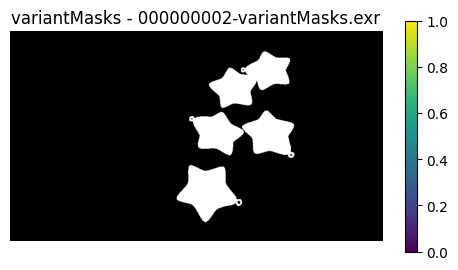

In [4]:
import os
import cv2
import numpy as np

import matplotlib.pyplot as plt

mask_dir = "/home/cago/MMI_714_generative_models/term_project/dataset/synthetic-test/star-bath-bomb-test/variant-masks/"

# list .exr files containing "variantMasks" in their name
mask_files = sorted(
    f for f in os.listdir(mask_dir)
    if f.lower().endswith(".exr") and "variantMasks" in f
)

# take up to 3
for i, fname in enumerate(mask_files[:3]):
    fpath = os.path.join(mask_dir, fname)
    mask = cv2.imread(fpath, cv2.IMREAD_UNCHANGED)

    if mask is None:
        print(f"Could not read {fname}")
        continue

    print(f"File {i+1}: {fname}")
    print(f"  - shape   : {mask.shape}")
    print(f"  - dtype   : {mask.dtype}")
    print(f"  - min/max : {np.nanmin(mask):.4f} / {np.nanmax(mask):.4f}")

    plt.figure(figsize=(6, 3))
    plt.title(f"variantMasks - {fname}")
    viz = mask.astype(np.float32).copy()
    viz[np.isinf(viz)] = np.nan
    if viz.ndim == 3 and viz.shape[2] == 3:
        viz = cv2.cvtColor(viz, cv2.COLOR_BGR2RGB)
    plt.imshow(viz, cmap="viridis" if viz.ndim == 2 else None)
    plt.axis("off")
    plt.colorbar()
    plt.show()